# Design Decision Optimization with the LQI Criterion

This tutorial follows the continuous steel-bar decision example in [Schubert and Faber (2009)](https://www.jcss-lc.org/publications/raie/11_example_jcss_ms_2.pdf). The cross-sectional area changes the resistance, FORM estimates the failure probability, and the economic optimum is compared with the minimum acceptable safety level from the LQI criterion.

The design decision optimization object in Pystra is `ra.DDO`. It does not change the stochastic model or the reliability method; it combines reliability results with an objective and an acceptability criterion. In this tutorial the objective is a cost-benefit model and the criterion is `ra.LQI`, which applies the LQI safety acceptance criterion using SWTP.

In [1]:
import numpy as np
import pystra as ra



## Reliability model

The limit state is written as

$$g(f_y, A_s, S) = f_y A_s - 1000 S$$

where `A_s` is the design variable. For each value of `A_s`, FORM computes the failure probability and reliability index.

In [2]:
def lsf(fy, As, S):
    return fy * As - 1000 * S


def run_reliability(As):
    limit_state = ra.LimitState(lsf)
    model = ra.StochasticModel()
    model.addVariable(ra.Lognormal("fy", 260, 18.2))
    model.addVariable(ra.Constant("As", As))
    model.addVariable(ra.Gumbel("S", 9.5, 1.5))

    options = ra.AnalysisOptions()
    options.setE1(1e-6)
    options.setE2(1e-6)

    form = ra.Form(
        analysis_options=options,
        limit_state=limit_state,
        stochastic_model=model,
    )
    form.run()
    return {"pf": float(np.atleast_1d(form.getFailure())[0]), "beta": form.getBeta()}

In [3]:
as_values = np.array([70, 75, 80, 85.1, 90, 93, 95, 100], dtype=float)
study = ra.DesignStudy(variable="As", values=as_values, analysis=run_reliability)

reliability = study.evaluate()
reliability

,As,pf,beta
0,70.0,0.000570,3.253631
1,75.0,0.000203,3.535666
2,80.0,0.000073,3.798064
3,85.1,0.000026,4.048903
4,90.0,0.000009,4.276350
5,93.0,0.000005,4.409851
6,95.0,0.000003,4.496640
7,100.0,0.000001,4.706519


## SWTP and the LQI target

Rackwitz's JCSS SWTP table is retained as a 1999 PPPUS$ anchor [Rackwitz (2008)](https://www.jcss-lc.org/publications/raie/06_risk_backgrounddoc_lqi_philosophy.pdf). For present-day studies, `indexed=True` returns an explicitly indexed value using World Bank GDP per capita PPP factors [World Bank WDI](https://data.worldbank.org/indicator/NY.GDP.PCAP.PP.CD). This keeps the literature value and the update method visible.

In [4]:
expected_fatalities_given_failure = 12
marginal_safety_cost = 5000

lqi = ra.LQI.from_country(
    "CH",
    indexed=True,
    expected_fatalities_given_failure=expected_fatalities_given_failure,
    marginal_safety_cost=marginal_safety_cost,
)

anchor = ra.SWTP.from_country("CH", indexed=False)
print(f"Rackwitz anchor: {anchor.value_per_life:,.0f} {anchor.currency} ({anchor.price_year})")
print(f"Indexed SWTP: {lqi.swtp.value_per_life:,.0f} {lqi.swtp.currency} ({lqi.swtp.price_year})")

Rackwitz anchor: 1,800,000 PPPUSD (1999)
Indexed SWTP: 4,999,502 current international PPPUSD (2024)


For the Fischer, Barnardo, and Faber target table [Fischer et al. (2012)](https://www.researchgate.net/publication/289533079_Deriving_target_reliabilities_from_the_LQI), define

$$K_1 = \frac{C_1}{\mathrm{SWTP} N_F}$$

where `C1` is the marginal safety cost and `N_F` is the expected number of fatalities given failure. `ra.LQI.from_country` computes this ratio and selects the corresponding target reliability.

In [5]:
print(f"K1 = {lqi.k1:.3g}")
print(f"target failure probability = {lqi.target.pf:.1e} per year")
print(
    f"target reliability index = {lqi.target.beta:.2f} "
    f"({lqi.target.cost_class} cost class, {lqi.target.variability} variability)"
)

K1 = 8.33e-05
target failure probability = 1.0e-05 per year
target reliability index = 4.20 (small cost class, medium variability)


## Economic objective and LQI feasibility

The economic objective below follows the JCSS steel-bar calculation [Schubert and Faber (2009)](https://www.jcss-lc.org/publications/raie/11_example_jcss_ms_2.pdf) with a constant annual benefit, construction cost proportional to `A_s`, and failure costs discounted over the service life.

In [6]:
economic_objective = ra.CostBenefitModel(
    benefit_rate=1.2e4,
    interest_rate=0.02,
    service_life=100,
    construction_cost=lambda As: 5000 * As,
    failure_cost=lambda As: 5000 * As + 12 * 1.8e6 + 3e4,
)

ddo = ra.DDO.lqi(study=study, objective=economic_objective, criterion=lqi)

results = ddo.run()
results["construction_cost"] = 5000 * results["As"]
results["jcss_lqi_risk_cost"] = lqi.risk_cost(
    results["construction_cost"],
    results["pf"],
)

results[[
    "As",
    "pf",
    "beta",
    "objective",
    "annualized_safety_cost",
    "target_pf",
    "lqi_acceptable",
    "jcss_lqi_risk_cost",
]]

,As,pf,beta,objective,annualized_safety_cost,target_pf,lqi_acceptable,jcss_lqi_risk_cost
0,70.0,0.000570,3.253631,-372721.781196,3497.986176,0.00001,False,384178.591097
1,75.0,0.000203,3.535666,-47463.728588,3749.229744,0.00001,False,387201.262612
2,80.0,0.000073,3.798064,52414.925067,3999.705431,0.00001,False,404374.488000
3,85.1,0.000026,4.048903,72134.235091,4254.889431,0.00001,False,427043.592996
4,90.0,0.000009,4.276350,63205.363591,4499.956828,0.00001,True,450569.891660
5,93.0,0.000005,4.409851,52360.698591,4649.975710,0.00001,True,465310.294518
6,95.0,0.000003,4.496640,44013.703577,4749.983441,0.00001,True,475207.086162
7,100.0,0.000001,4.706519,21121.311353,4999.993638,0.00001,True,500075.587349


In [7]:
economic_best = ddo.maximize_unconstrained_objective()
feasible_best = ddo.optimize()

for label, row in [
    ("unconstrained economic optimum", economic_best),
    ("best LQI-feasible alternative", feasible_best),
]:
    print(
        f"{label}: As = {row['As']:.1f} mm^2, "
        f"pf = {row['pf']:.2e} per year, "
        f"Z = {row['objective']:,.0f} CHF, "
        f"LQI acceptable = {row['lqi_acceptable']}"
    )

unconstrained economic optimum: As = 85.1 mm^2, pf = 2.57e-05 per year, Z = 72,134 CHF, LQI acceptable = False
best LQI-feasible alternative: As = 90.0 mm^2, pf = 9.50e-06 per year, Z = 63,205 CHF, LQI acceptable = True


Text(0.5, 1.0, 'Economic objective and LQI target')

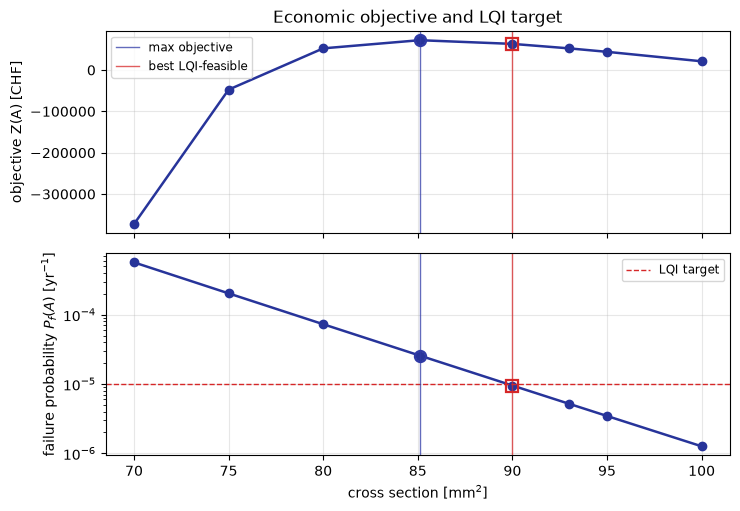

In [8]:
fig, axes = ddo.plot(
    quantities=["objective", "pf"],
    labels={
        "As": r"cross section [mm$^2$]",
        "objective": "objective Z(A) [CHF]",
        "pf": r"failure probability $P_f(A)$ [yr$^{-1}$]",
    },
    reference_designs=[
        {"design": economic_best["As"], "label": "max objective", "marker": "o"},
        {"design": feasible_best["As"], "label": "best LQI-feasible", "marker": "s"},
    ],
    target_failure_probability=lqi.target.pf,
    figsize=(7.5, 5.0),
)
axes[0].set_title("Economic objective and LQI target")

## Schubert and Faber summary plot

Schubert and Faber's JCSS steel-bar example combines the failure probability, annualized safety cost, marginal LQI condition, and objective in one continuous-design summary. The next cell builds those quantities from the same reliability model and Table 1 parameters; the plotting call is intentionally generic, so it can be reused for other one-dimensional LQI design studies.

In [9]:
from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq, minimize_scalar


jcss_designs = np.linspace(70.0, 100.0, 61)
jcss_curve = ra.DesignStudy("As", jcss_designs, run_reliability).evaluate()
jcss_pf = PchipInterpolator(jcss_curve["As"], jcss_curve["pf"])

paper_lqi = ra.LQI.from_lqi(
    gross_domestic_product_per_capita=35931.0,
    mortality_rate=0.175,
    demographic_constant=18.9,
    expected_fatalities_given_failure=12,
    marginal_safety_cost=5000,
    currency="CHF",
    price_year=2009,
    source="Schubert and Faber (2009), Table 1",
)

publication_objective = ra.CostBenefitModel(
    benefit_rate=1.2e4,
    interest_rate=0.02,
    service_life=100,
    construction_cost=lambda As: 5000 * As,
    failure_cost=lambda As: 5000 * As + 12 * 1.8e6 + 3e4,
)


def pf_at(As):
    return float(jcss_pf(As))


def annualized_cost(As):
    return publication_objective.annualized_safety_cost(As, pf_at(As))


def objective_at(As):
    return publication_objective.objective(As, pf_at(As))


def marginal_lqi_term(As):
    margin = paper_lqi.marginal_acceptance(annualized_cost, pf_at, As, step=1e-3)
    return -margin / paper_lqi.swtp.for_lives(
        paper_lqi.expected_fatalities_given_failure
    )


optimal_as = float(
    minimize_scalar(lambda As: -objective_at(As), bounds=(70.0, 100.0), method="bounded").x
)
acceptable_as = float(brentq(marginal_lqi_term, 80.0, 100.0))

jcss_curve["annualized_safety_cost"] = [annualized_cost(As) / 1e3 for As in jcss_curve["As"]]
jcss_curve["lqi_marginal_term"] = [marginal_lqi_term(As) * 1e5 for As in jcss_curve["As"]]
jcss_curve["objective"] = [objective_at(As) for As in jcss_curve["As"]]

for label, As, reported in [
    ("economic optimum", optimal_as, 85.1),
    ("LQI acceptance boundary", acceptable_as, 93.0),
]:
    print(
        f"{label}: As = {As:.1f} mm^2 (published {reported:.1f}), "
        f"pf = {pf_at(As):.2e} per year, "
        f"Cy = {annualized_cost(As) / 1e3:.2f}e3 CHF/year, "
        f"Z = {objective_at(As):,.0f} CHF"
    )

economic optimum: As = 85.1 mm^2 (published 85.1), pf = 2.56e-05 per year, Cy = 4.26e3 CHF/year, Z = 72,134 CHF
LQI acceptance boundary: As = 92.9 mm^2 (published 93.0), pf = 5.30e-06 per year, Cy = 4.64e3 CHF/year, Z = 52,860 CHF


Text(0.5, 1.01, 'Schubert and Faber JCSS steel-bar example')

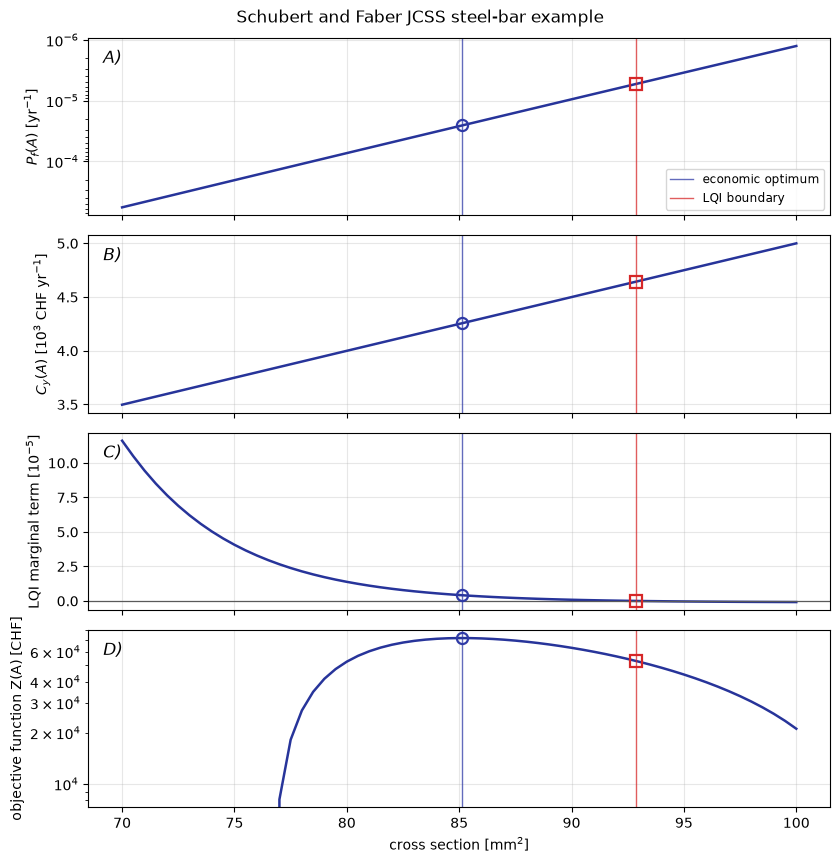

In [10]:
fig, axes = ra.ddo.plot_summary(
    jcss_curve,
    design="As",
    quantities=["pf", "annualized_safety_cost", "lqi_marginal_term", "objective"],
    labels={
        "As": r"cross section [mm$^2$]",
        "pf": r"$P_f(A)$ [yr$^{-1}$]",
        "annualized_safety_cost": r"$C_y(A)$ [$10^3$ CHF yr$^{-1}$]",
        "lqi_marginal_term": r"LQI marginal term [$10^{-5}$]",
        "objective": "objective function Z(A) [CHF]",
    },
    yscales={"pf": "log", "objective": "log"},
    invert_yaxis=["pf"],
    panel_labels=True,
    reference_designs=[
        {"design": optimal_as, "label": "economic optimum", "marker": "o"},
        {"design": acceptable_as, "label": "LQI boundary", "marker": "s"},
    ],
    figsize=(8.5, 8.5),
    line_kwargs={"marker": ""},
)
fig.suptitle("Schubert and Faber JCSS steel-bar example", y=1.01)
